# Zhang–Duan equation of state: reduced variables, parameters, and a mantle-fluid example

The [Zhang–Duan (2009) equation of state](https://doi.org/10.1016/j.gca.2009.01.021) is a corresponding-states correlation for dense C–O–H molecular fluids. Unlike the Peng–Robinson cubic EOS, it is intended primarily for the high-temperature, high-pressure conditions of Earth's mantle. It correlates the physical compressibility factor

$$
Z=\frac{PV}{RT}=\frac{P}{\rho RT},
$$

where $V=1/\rho$ is physical molar volume. Define an energy scale $\theta=\epsilon_{\mathrm{mix}}/k_B$, a size scale $\sigma=\sigma_{\mathrm{mix}}$, and the reduced variables

$$
T_m=\frac{154T}{\theta},
\qquad
\delta=\frac{\rho}{1000\ \mathrm{mol\,m^{-3}}}
\left(\frac{\sigma}{3.691\times10^{-10}\ \mathrm{m}}\right)^3.
$$

With four temperature-dependent coefficients

$$
\begin{aligned}
B(T_m)&=a_1+\frac{a_2}{T_m^2}+\frac{a_3}{T_m^3}, &
C(T_m)&=a_4+\frac{a_5}{T_m^2}+\frac{a_6}{T_m^3},\\
D(T_m)&=a_7+\frac{a_8}{T_m^2}+\frac{a_9}{T_m^3}, &
E(T_m)&=a_{10}+\frac{a_{11}}{T_m^2}+\frac{a_{12}}{T_m^3},
\end{aligned}
$$

the EOS used by ExoEOS is

$$
\boxed{
Z=1+B\delta+C\delta^2+D\delta^4+E\delta^5
+\frac{a_{13}}{T_m^3}\delta^2
\left(a_{14}+a_{15}\delta^2\right)
e^{-a_{15}\delta^2}
},
\qquad P=\rho RTZ.
$$

Thus $Z\rightarrow1$ as $\rho\rightarrow0$. The polynomial and damped-exponential terms form one empirical correlation; they do not separate into the simple repulsive and attractive terms of a cubic EOS.

ExoEOS integrates this equation into a reduced residual molar Helmholtz energy. Setting $q=a_{15}\delta^2$,

$$
\alpha^r=\frac{A^r}{nRT}
=B\delta+\frac{C}{2}\delta^2+\frac{D}{4}\delta^4
+\frac{E}{5}\delta^5
+\frac{a_{13}}{2a_{15}T_m^3}
\left[(a_{14}+1)(1-e^{-q})-qe^{-q}\right].
$$

It then obtains pressure and residual chemical potentials consistently by differentiation,

$$
P=\rho RT\left[1+\rho
\left(\frac{\partial\alpha^r}{\partial\rho}\right)_{T,\boldsymbol{x}}\right],
\qquad
\ln\phi_i=\frac{\mu_i^r}{RT}-\ln Z.
$$

The right-hand side of the paper's Equation 8 is used with the physical $Z=PV/(RT)$. ExoEOS does not apply the additional scaling printed on that equation's left-hand side because doing so does not reproduce the paper's Table 6 volumes. Fugacities are differentiated from $\alpha^r$ rather than transcribed from the paper's mixture fugacity expression.

## Required parameters

A pure Zhang–Duan fluid needs **two species-specific parameters**, not the three Peng–Robinson properties $(T_c,P_c,\omega)$:

| Input | Unit | Role |
|---|---:|---|
| $\theta_i=\epsilon_i/k_B$ | K | Effective Lennard–Jones energy scale; it sets $T_m$. |
| $\sigma_i$ | m in the API | Effective molecular diameter; it sets the density scale $\delta$. |

These are fitted corresponding-states parameters, not measured critical properties or literal molecular dimensions. `ZhangDuanEOS.from_species` loads the published values:

| Species | $\epsilon_i/k_B$ [K] | $\sigma_i$ [Å] |
|---|---:|---:|
| CH₄ | 154.0 | 3.691 |
| H₂O | 510.0 | 2.88 |
| CO₂ | 235.0 | 3.79 |
| H₂ | 31.2 | 2.93 |
| CO | 105.6 | 3.66 |
| O₂ | 124.5 | 3.36 |
| C₂H₆ | 246.1 | 4.35 |

For a mixture, normalized mole fractions $x_i$ and two symmetric, dimensionless interaction matrices are also needed. The Lorentz–Berthelot-type rules are

$$
\theta=\sum_i\sum_j x_i x_j k_{1,ij}
\sqrt{\theta_i\theta_j},
\qquad
\sigma=\sum_i\sum_j x_i x_j k_{2,ij}
\frac{\sigma_i+\sigma_j}{2}.
$$

Here $k_{1,ij}$ scales unlike-pair energy and $k_{2,ij}$ scales unlike-pair size. The neutral value is **one**, unlike the zero-valued $k_{ij}$ convention commonly used by Peng–Robinson implementations. The published fitted pairs are

| Pair | $k_{1,ij}$ | $k_{2,ij}$ |
|---|---:|---:|
| H₂O–CO₂ | 0.85 | 1.02 |
| H₂O–CH₄ | 0.80 | 1.00 |

Diagonal entries and all other pairs default to one. For an unfitted pair, one is an approximation rather than a validated interaction parameter. In the direct constructor, the four model inputs are therefore `epsilon_over_k` with shape `(N,)`, `molecular_diameters` with shape `(N,)`, and optional `energy_interaction_parameters` and `size_interaction_parameters`, each with shape `(N, N)`. Temperature, pressure or density, and composition are state inputs rather than stored model parameters.

The 15 universal coefficients below are fixed for every species and mixture. They are part of the EOS definition, not additional caller inputs.

| Coefficient | Value | Coefficient | Value | Coefficient | Value |
|---:|---:|---:|---:|---:|---:|
| $a_1$ | $2.95177298930\times10^{-2}$ | $a_6$ | $7.65938947237\times10^4$ | $a_{11}$ | $5.35026383543\times10^{-3}$ |
| $a_2$ | $-6.33756452413\times10^3$ | $a_7$ | $2.58661493537\times10^{-6}$ | $a_{12}$ | $-2.71106499510\times10^{-1}$ |
| $a_3$ | $-2.75265428882\times10^5$ | $a_8$ | $5.21265321460\times10^{-1}$ | $a_{13}$ | $2.50387836486\times10^4$ |
| $a_4$ | $1.29128089283\times10^{-3}$ | $a_9$ | $-1.39839523753\times10^2$ | $a_{14}$ | $7.32267260410\times10^{-1}$ |
| $a_5$ | $-1.45797416153\times10^2$ | $a_{10}$ | $-2.36335007175\times10^{-8}$ | $a_{15}$ | $1.54833359970\times10^{-2}$ |

## H₂O–CO₂ at mantle conditions

A more representative Zhang–Duan example than a low-temperature critical isotherm is the H₂O–CO₂ system at $T=1573.15$ K and $P=1.45$ GPa. These are the conditions used in Figure 1 of the original paper and lie inside the fitted H₂O–CO₂ range. The example also exercises both species parameters and the published binary parameters. We first evaluate a mixture with $x_{\mathrm{H_2O}}=0.75$.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/exoeos_matplotlib")

from jax import config

config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from exoeos import (
    PengRobinsonEOS,
    ZhangDuanEOS,
    get_critical_properties,
    state_tp,
)

species = ("H2O", "CO2")
eos = ZhangDuanEOS.from_species(species)
temperature = 1573.15  # K
pressure = 1.45e9  # Pa
composition = jnp.asarray([0.75, 0.25])
state = state_tp(eos, temperature, pressure, composition)
volume_cm3_mol = 1.0e6 / state.rho

np.testing.assert_allclose(state.P, pressure, rtol=2.0e-12)
np.testing.assert_allclose(
    state.gres_RT, composition @ state.lnphi, rtol=2.0e-12
)

print("species                 =", species)
print("epsilon_i/k_B [K]      =", np.asarray(eos.epsilon_over_k))
print("sigma_i [angstrom]     =", np.asarray(eos.molecular_diameters) / 1.0e-10)
print("k1                     =\n", np.asarray(eos.energy_interaction_parameters))
print("k2                     =\n", np.asarray(eos.size_interaction_parameters))
print(f"rho                    = {float(state.rho):.6f} mol m^-3")
print(f"V                      = {float(volume_cm3_mol):.6f} cm^3 mol^-1")
print(f"Z                      = {float(state.Z):.9f}")
print(f"alpha^r                = {float(state.alphar):.9f}")
print("ln(phi_i)              =", np.asarray(state.lnphi))
print(f"g^r/(RT)               = {float(state.gres_RT):.9f}")

species                 = ('H2O', 'CO2')
epsilon_i/k_B [K]      = [510. 235.]
sigma_i [angstrom]     = [2.88 3.79]
k1                     =
 [[1.   0.85]
 [0.85 1.  ]]
k2                     =
 [[1.   1.02]
 [1.02 1.  ]]
rho                    = 38411.916052 mol m^-3
V                      = 26.033588 cm^3 mol^-1
Z                      = 2.886009202
alpha^r                = 0.826874625
ln(phi_i)              = [1.05218948 3.45546827]
g^r/(RT)               = 1.653009178


The following composition sweep follows the $x_{\mathrm{H_2O}}=0.60$–$0.90$ interval shown in the paper. The solid line uses the fitted H₂O–CO₂ pair. The dashed line sets both unlike-pair parameters to one while retaining the same pure-species parameters, making the effect of $k_1$ and $k_2$ explicit. A Peng–Robinson PR76 curve is included for reference using the bundled $(T_c,P_c,\omega)$ values and $k_{ij}=0$. It is a qualitative comparison, not a calibrated PR prediction: no H₂O–CO₂ binary parameter is fitted here, and unmodified PR is not expected to be quantitatively reliable for a dense, polar, water-rich fluid at 1.45 GPa.

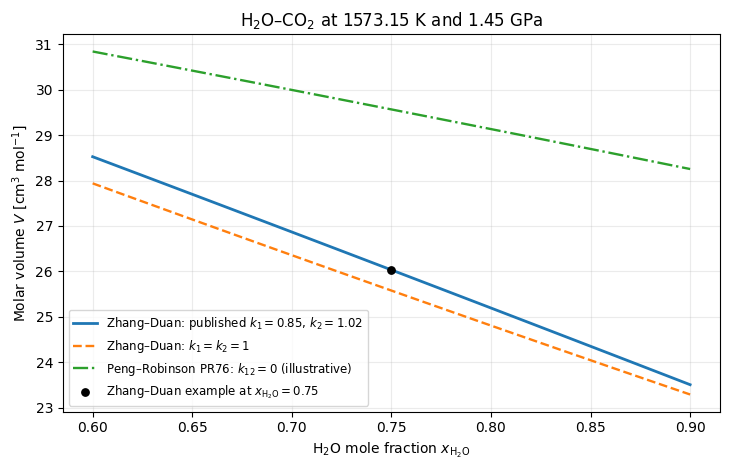

In [2]:
water_fractions = jnp.linspace(0.60, 0.90, 121)
compositions = jnp.column_stack((water_fractions, 1.0 - water_fractions))
unity_interaction_eos = ZhangDuanEOS(
    eos.epsilon_over_k,
    eos.molecular_diameters,
)
critical_properties = tuple(
    get_critical_properties(name) for name in species
)
peng_robinson_eos = PengRobinsonEOS(
    critical_temperatures=jnp.asarray(
        [record.critical_temperature for record in critical_properties]
    ),
    critical_pressures=jnp.asarray(
        [record.critical_pressure for record in critical_properties]
    ),
    acentric_factors=jnp.asarray(
        [record.acentric_factor for record in critical_properties]
    ),
    binary_interaction_parameters=jnp.zeros((2, 2)),  # illustrative
)

def molar_volume(model, x):
    return 1.0e6 / state_tp(model, temperature, pressure, x).rho

published_volumes = np.asarray(
    jax.vmap(lambda x: molar_volume(eos, x))(compositions)
)
unity_volumes = np.asarray(
    jax.vmap(lambda x: molar_volume(unity_interaction_eos, x))(compositions)
)
peng_robinson_volumes = np.asarray(
    jax.vmap(lambda x: molar_volume(peng_robinson_eos, x))(compositions)
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(
    water_fractions,
    published_volumes,
    linewidth=2.0,
    label=r"Zhang–Duan: published $k_1=0.85$, $k_2=1.02$",
)
ax.plot(
    water_fractions,
    unity_volumes,
    linestyle="--",
    linewidth=1.7,
    label=r"Zhang–Duan: $k_1=k_2=1$",
)
ax.plot(
    water_fractions,
    peng_robinson_volumes,
    color="tab:green",
    linestyle="-.",
    linewidth=1.7,
    label=r"Peng–Robinson PR76: $k_{12}=0$ (illustrative)",
)
ax.scatter(
    [float(composition[0])],
    [float(volume_cm3_mol)],
    color="black",
    s=28,
    zorder=3,
    label=r"Zhang–Duan example at $x_{\mathrm{H_2O}}=0.75$",
)
ax.set(
    xlabel=r"H$_2$O mole fraction $x_{\mathrm{H_2O}}$",
    ylabel=r"Molar volume $V$ [cm$^3$ mol$^{-1}$]",
    title=r"H$_2$O–CO$_2$ at 1573.15 K and 1.45 GPa",
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

The Zhang–Duan volume decreases across this interval as H₂O replaces CO₂. The separation between its two curves is the contribution of the fitted unlike-pair parameters; those curves would coincide at either pure end member. The larger PR76 volume illustrates sensitivity to the EOS and binary-interaction assumption at this high pressure, but it must not be read as evidence that either model is more accurate without comparison to reference data and a defensible PR binary parameter. Every point is a prescribed, homogeneous composition. This sweep is not a reaction-equilibrium or phase-equilibrium path.

## Scope and practical cautions

The ranges below are the envelopes of experimental and molecular-dynamics data reported in Tables 5 and 7 of Zhang and Duan (2009), not guarantees that every state inside each bounding rectangle has equal accuracy. The two directly calibrated mixtures are

| Mixture | Temperature [K] | Pressure [MPa] | Reported mean volume deviation |
|---|---:|---:|---:|
| H₂O–CO₂ | 673–2573 | 1–10,000 | 1.12% |
| H₂O–CH₄ | 673–2573 | 10–10,000 | 1.97% |

Pure-species data ranges differ substantially:

| Species | Experimental-data range | Molecular-dynamics range |
|---|---|---|
| CH₄ | 273–723 K, 0.1–1015.5 MPa | 673–2573 K, 50–10,000 MPa |
| CO₂ | 473–1100 K, 0.1–800 MPa | 673–2573 K, 800–10,000 MPa |
| H₂O | 673–1873 K, 0.1–5000 MPa | 673–2573 K, 800–10,000 MPa |
| H₂ | 250–423 K, 2–700 MPa | — |
| CO | 300–573.2 K, 10–1020.6 MPa | — |
| O₂ | 300–1000 K, 7–1013.2 MPa | — |
| C₂H₆ | 373–673 K, 30–900 MPa | — |

Evaluation outside the relevant reported range is extrapolation. In particular, the broad H₂O–CO₂ or H₂O–CH₄ range should not be assigned automatically to every pure species or every possible binary pair.

Additional boundaries of the ExoEOS implementation are:

- `ZhangDuanEOS` describes one homogeneous molecular fluid. It does not perform vapor–liquid separation, global phase-stability analysis, or a flash calculation.
- `state_tp(..., phase="vapor")` selects the first mechanically stable root connected to the low-density branch. `"vapor"` is the common API selector even when the high-pressure state is a dense fluid; it is not proof of vapor stability.
- The class implements the PVT/residual-fugacity EOS portion of the 2009 work. The paper's reaction-speciation minimization, standard chemical potentials, and solid-carbon phases are separate and are not included.
- Only H₂O–CO₂ and H₂O–CH₄ have fitted binary parameters in `from_species`; all other unlike pairs use the unity approximation.
- Absolute enthalpy, entropy, and heat capacity require ideal-gas reference contributions in addition to this residual EOS.

For the correlation, parameter tables, and validation data, see [Zhang and Duan (2009)](https://doi.org/10.1016/j.gca.2009.01.021).